# 03 · Part B — Observational Causal Inference

What if we couldn't randomize and only observed who got the offer? We manufacture selection bias so treatment depends on `history`, show a naïve comparison gives the wrong answer, then recover the true effect with a DAG, propensity scores, PSM, IPW, and DoWhy's refutation workflow. The benchmark to recover is Part A's true conversion ATE, **+0.495 pp**.

> Difference-in-Differences is not run on Hillstrom — it is a single post-treatment snapshot with no pre-period. DiD is demonstrated on valid panel data in the appendix.

In [1]:
import sys, warnings, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")
logging.getLogger("dowhy").setLevel(logging.ERROR)

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_prep as dp
from src import causal as cz

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

OUTCOME, PP = "conversion", 100
df = dp.add_treatment_flag(dp.load_raw())
true_ate = df[df.treatment == 1][OUTCOME].mean() - df[df.treatment == 0][OUTCOME].mean()
print(f"True RCT ATE (conversion) = {true_ate*PP:+.3f} pp   <- the benchmark to recover")

True RCT ATE (conversion) = +0.495 pp   <- the benchmark to recover


## 1. Manufacture selection bias

Keep customers with a probability depending on treatment and `history`: treated more often when past spend is high, control more often when it is low — entangling the offer with a confounder.

In [2]:
biased = cz.inject_selection_bias(df, seed=42)
h = biased.groupby("treatment").history.mean()
print(f"biased sample: {len(biased):,} rows  "
      f"(treated {int(biased.treatment.sum()):,}, control {int((1-biased.treatment).sum()):,})")
print(f"mean history — treated ${h[1]:.0f}  vs  control ${h[0]:.0f}   (full data ${df.history.mean():.0f})")

biased sample: 31,977 rows  (treated 21,360, control 10,617)
mean history — treated $329  vs  control $156   (full data $242)


In [3]:
bt_biased = dp.balance_table(biased)
print("Worst covariate imbalances now (|SMD| > 0.1 means broken balance):")
bt_biased.head(6).round(3)

Worst covariate imbalances now (|SMD| > 0.1 means broken balance):


,feature,smd,abs_smd,balanced
0,history_segment_ord,0.806,0.806,False
1,history,0.714,0.714,False
2,channel_Multichannel,0.343,0.343,False
3,recency,-0.182,0.182,False
4,channel_Phone,-0.121,0.121,False
5,womens,0.104,0.104,False


The groups are now badly imbalanced (some |SMD| far above 0.1) — treatment and `history` are entangled, so a plain comparison is untrustworthy.

## 2. The naïve estimate

In [4]:
naive = cz.naive_effect(biased, OUTCOME)
print(f"NAIVE estimate = {naive['estimate']*PP:+.3f} pp   95% CI [{naive['ci_low']*PP:+.3f}, {naive['ci_high']*PP:+.3f}]")
print(f"TRUE RCT ATE   = {true_ate*PP:+.3f} pp")
print(f"=> naïve OVERSTATES by {(naive['estimate']-true_ate)*PP:+.3f} pp "
      f"({naive['estimate']/true_ate-1:+.0%}) — it credits the offer for loyalty it didn't cause.")

NAIVE estimate = +0.704 pp   95% CI [+0.504, +0.904]
TRUE RCT ATE   = +0.495 pp
=> naïve OVERSTATES by +0.208 pp (+42%) — it credits the offer for loyalty it didn't cause.


## 3. The causal DAG & the backdoor criterion

The confounders X cause both treatment T and outcome Y, opening a backdoor path T ← X → Y. Blocking it by adjusting for X leaves the true T → Y effect. We adjust for confounders, not colliders or mediators.

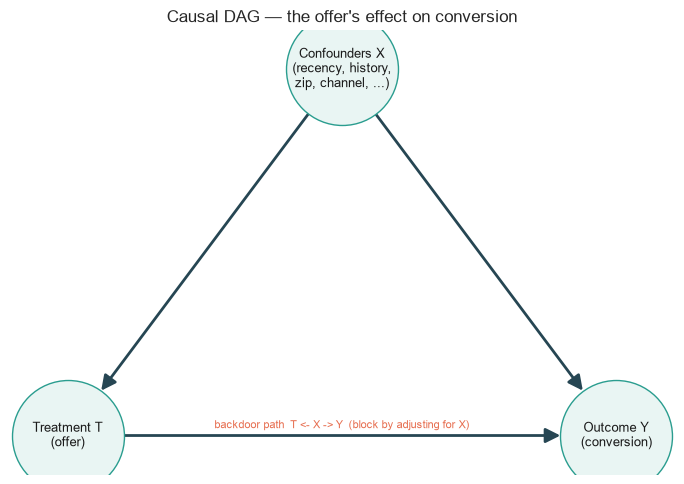

In [5]:
cz.draw_causal_dag(save_path=FIG_DIR / "03_causal_dag.png"); plt.show()

## 4. Propensity scores & overlap

The propensity score e(x) = P(treated | features) summarizes the confounders. We check overlap (common support) before using it: every customer type must have some chance of either group.

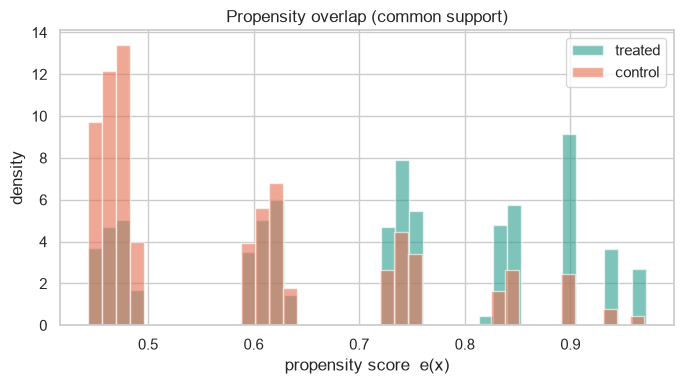

treated ps [0.44, 0.97]   control ps [0.44, 0.97]


In [6]:
ps, ps_model = cz.fit_propensity(biased)
T = biased.treatment.values
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ps[T == 1], bins=40, alpha=0.6, density=True, label="treated", color="#2a9d8f")
ax.hist(ps[T == 0], bins=40, alpha=0.6, density=True, label="control", color="#e76f51")
ax.set_xlabel("propensity score  e(x)"); ax.set_ylabel("density")
ax.set_title("Propensity overlap (common support)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "03_propensity_overlap.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"treated ps [{ps[T==1].min():.2f}, {ps[T==1].max():.2f}]   "
      f"control ps [{ps[T==0].min():.2f}, {ps[T==0].max():.2f}]")

## 5. Propensity Score Matching (PSM)

Match each treated customer to the nearest control by propensity (logit scale, with a caliper) and compare within pairs to estimate the ATT, then re-check balance.

In [7]:
psm = cz.psm_att(biased, OUTCOME, ps)
matched = cz.matched_sample(biased, psm)
bt_matched = dp.balance_table(matched)
print(f"PSM ATT = {psm['att']*PP:+.3f} pp   (matched {psm['matched_fraction']:.0%}, n={psm['n_matched']:,})")
print(f"balance max|SMD|:  biased {bt_biased.abs_smd.max():.3f}  ->  after matching {bt_matched.abs_smd.max():.3f}")

PSM ATT = +0.534 pp   (matched 100%, n=21,360)
balance max|SMD|:  biased 0.806  ->  after matching 0.028


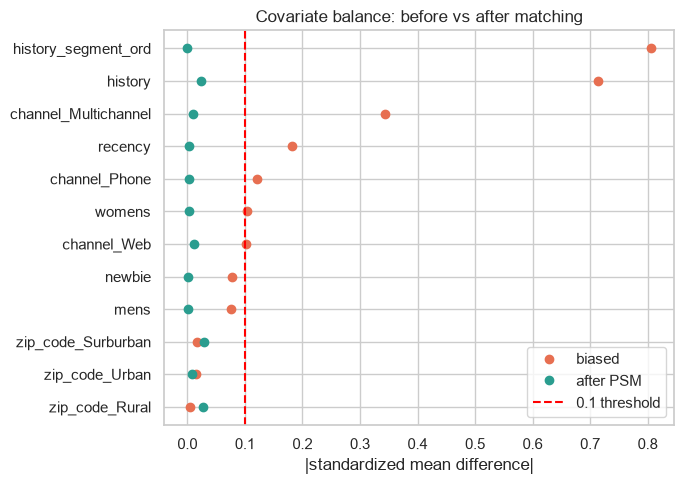

In [8]:
comp = (bt_biased[["feature", "abs_smd"]]
        .merge(bt_matched[["feature", "abs_smd"]], on="feature", suffixes=("_biased", "_matched"))
        .sort_values("abs_smd_biased"))
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(comp.abs_smd_biased, comp.feature, "o", color="#e76f51", label="biased")
ax.plot(comp.abs_smd_matched, comp.feature, "o", color="#2a9d8f", label="after PSM")
ax.axvline(0.1, color="red", ls="--", label="0.1 threshold")
ax.set_xlabel("|standardized mean difference|"); ax.set_title("Covariate balance: before vs after matching")
ax.legend(); fig.tight_layout()
fig.savefig(FIG_DIR / "03_balance_before_after.png", dpi=120, bbox_inches="tight"); plt.show()

Matching pulled every covariate back under 0.1 — the matched groups are comparable, and the ATT lands close to the true RCT effect.

## 6. Inverse-Propensity Weighting (IPW)

Weight each customer by 1/e(x) (treated) or 1/(1−e(x)) (control) so the weighted groups resemble the same population.

In [9]:
ipw = cz.ipw_ate(biased, OUTCOME, ps)
print(f"IPW ATE = {ipw*PP:+.3f} pp   (true RCT ATE = {true_ate*PP:+.3f} pp)")

IPW ATE = +0.582 pp   (true RCT ATE = +0.495 pp)


## 7. The punchline — naïve vs corrected vs the truth

Bootstrap confidence intervals (resample, refit propensity, recompute) put error bars on each method.

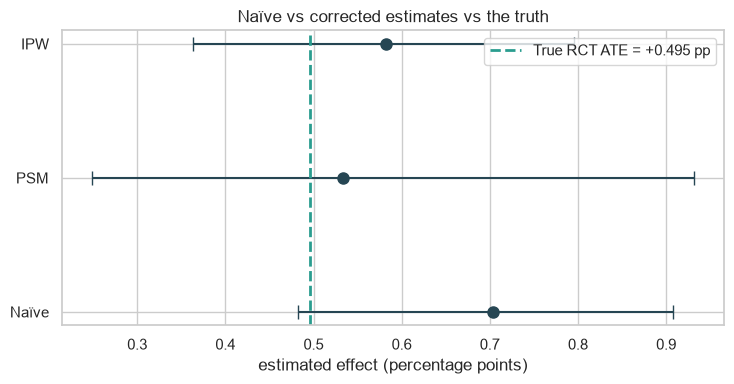

  naive  = +0.704 pp   95% CI [+0.482, +0.908]
  psm    = +0.534 pp   95% CI [+0.249, +0.932]
  ipw    = +0.582 pp   95% CI [+0.363, +0.796]


In [10]:
boot = cz.bootstrap_estimates(biased, OUTCOME, n_boot=200, seed=0)
def ci(a): return np.percentile(a, 2.5), np.percentile(a, 97.5)

labels = ["Naïve", "PSM", "IPW"]
keys = ["naive", "psm", "ipw"]
ests = [naive["estimate"], psm["att"], ipw]
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, (k, est) in enumerate(zip(keys, ests)):
    lo, hi = ci(boot[k])
    ax.errorbar(est*PP, i, xerr=[[(est-lo)*PP], [(hi-est)*PP]], fmt="o",
                color="#264653", capsize=5, ms=8)
ax.axvline(true_ate*PP, color="#2a9d8f", ls="--", lw=2, label=f"True RCT ATE = {true_ate*PP:+.3f} pp")
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("estimated effect (percentage points)")
ax.set_title("Naïve vs corrected estimates vs the truth"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "03_punchline_naive_vs_corrected.png", dpi=120, bbox_inches="tight")
plt.show()
for k, est in zip(keys, ests):
    lo, hi = ci(boot[k])
    print(f"  {k:6} = {est*PP:+.3f} pp   95% CI [{lo*PP:+.3f}, {hi*PP:+.3f}]")

The naïve estimate sits above the truth; PSM and IPW move back onto it, with CIs that include the true RCT ATE — the causal effect recovered from biased data.

## 8. DoWhy — identify → estimate → refute

DoWhy derives which variables to adjust for, estimates the effect, and tries to break it:

- **placebo:** replace treatment with random noise — the effect should collapse to ~0.
- **random common cause:** add an irrelevant confounder — the estimate should barely move.
- **data subset:** re-estimate on 80% of the data — the estimate should barely move.

In [11]:
dw = cz.dowhy_analysis(biased, OUTCOME, n_sim=100)
pd.DataFrame([
    {"step": "estimate (backdoor linear)", "value_pp": dw["estimate"]*PP, "expectation": "≈ true RCT ATE"},
    {"step": "placebo (permute T)",        "value_pp": dw["placebo_effect"]*PP,
     "expectation": f"≈ 0  (p={dw['placebo_p']:.2f} → not significant = pass)"},
    {"step": "random common cause",        "value_pp": dw["random_cc_effect"]*PP, "expectation": "≈ estimate"},
    {"step": "data subset (80%)",          "value_pp": dw["subset_effect"]*PP,   "expectation": "≈ estimate"},
]).round(3)

,step,value_pp,expectation
0,estimate (backdoor linear),0.467,≈ true RCT ATE
1,placebo (permute T),0.004,≈ 0 (p=0.86 → not significant = pass)
2,random common cause,0.467,≈ estimate
3,data subset (80%),0.484,≈ estimate


All three refuters pass: the placebo effect collapses to ~0 (not significant), and the estimate is stable under a random common cause and on data subsets.

## 9. Assumptions

- **Unconfoundedness:** given the measured covariates, treatment is independent of the potential outcomes. It holds here by construction (bias was injected using only observed features); in the real world it can't be guaranteed, hence the refutation tests.
- **Overlap / positivity:** every customer type has a non-zero chance of either group (checked via propensity overlap).
- **SUTVA:** one customer's treatment doesn't affect another's outcome, and there's a single version of the offer.

## Appendix · Difference-in-Differences (on valid panel data)

DiD needs the same outcome measured before and after for both groups and corrects for time-invariant group differences plus a common time trend — a different problem from the cross-sectional selection bias above. Hillstrom has no pre-period, so we demonstrate DiD on a synthetic panel with a known effect.

In [12]:
rng = np.random.default_rng(7)
n, true_did = 3000, 3.0
c_pre,  c_post = rng.normal(10, 2, n), rng.normal(12, 2, n)               # control: +2 time trend
t_pre,  t_post = rng.normal(8, 2, n),  rng.normal(8 + 2 + true_did, 2, n) # treated: +2 trend + effect
did = (t_post.mean() - t_pre.mean()) - (c_post.mean() - c_pre.mean())
print(f"true injected effect = {true_did:.2f}")
print(f"DiD estimate         = {did:.2f}   (= treated change - control change)")

true injected effect = 3.00
DiD estimate         = 3.00   (= treated change - control change)


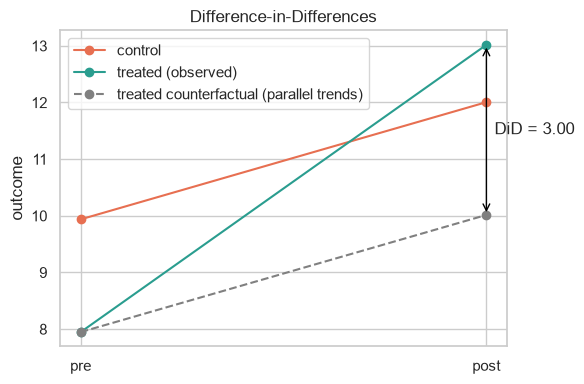

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, 1], [c_pre.mean(), c_post.mean()], "o-", color="#e76f51", label="control")
ax.plot([0, 1], [t_pre.mean(), t_post.mean()], "o-", color="#2a9d8f", label="treated (observed)")
counterfactual = t_pre.mean() + (c_post.mean() - c_pre.mean())
ax.plot([0, 1], [t_pre.mean(), counterfactual], "o--", color="grey",
        label="treated counterfactual (parallel trends)")
ax.annotate("", xy=(1, t_post.mean()), xytext=(1, counterfactual),
            arrowprops=dict(arrowstyle="<->", color="black"))
ax.text(1.02, (t_post.mean()+counterfactual)/2, f"DiD = {did:.2f}", va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pre", "post"]); ax.set_ylabel("outcome")
ax.set_title("Difference-in-Differences"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "03_did_demo.png", dpi=120, bbox_inches="tight"); plt.show()

DiD recovers the injected effect. Its key assumption is **parallel trends**: absent treatment the two groups would have moved in parallel (grey dashed line).

## Part B takeaways from the above results

- A naïve comparison on biased data overstated the effect by ~40%.
- PSM restored covariate balance (max |SMD| from ~0.8 back under 0.1) and IPW re-weighted the groups; both recovered the true RCT ATE with bootstrap CIs covering it.
- DoWhy identified the estimand and the effect survived placebo, random-common-cause, and subset refutation.
- Assumptions stated (unconfoundedness, overlap, SUTVA), with DiD demonstrated where it is valid.